# Iterators and Generators

In this section of the course we will be learning the difference between iteration and generation in Python and how to construct our own Generators with the *yield* statement. Generators allow us to generate as we go along, instead of holding everything in memory. 

We've touched on this topic in the past when discussing certain built-in Python functions like **range()**, **map()** and **filter()**.

Let's explore a little deeper. We've learned how to create functions with <code>def</code> and the <code>return</code> statement. Generator functions allow us to write a function that can send back a value and then later resume to pick up where it left off. This type of function is a generator in Python, allowing us to generate a sequence of values over time. The main difference in syntax will be the use of a <code>yield</code> statement.

In most aspects, a generator function will appear very similar to a normal function. The main difference is when a generator function is compiled they become an object that supports an iteration protocol. That means when they are called in your code they don't actually return a value and then exit. Instead, generator functions will automatically suspend and resume their execution and state around the last point of value generation. The main advantage here is that instead of having to compute an entire series of values up front, the generator computes one value and then suspends its activity awaiting the next instruction. This feature is known as *state suspension*.


￼￼To start getting a better understanding of generators, let's go ahead and see how we can create some.

In [1]:
def my_gen():
    yield 1
    yield 2

# Create ONE generator object
g = my_gen()

# First time: Works!
for x in g:
    print(x) # Prints 1, 2

# Second time: NOTHING HAPPENS
for x in g:
    print(x) # Prints nothing! The "bookmark" is at the end.
    
print(f"creaitng one more generator object: new_g")
new_g = my_gen()
for x in new_g:
  print(x)
print(f"trying to reassign a generator object to old var")
#This also works
g = my_gen()
for x in g:
  print(x)

1
2
creaitng one more generator object: new_g
1
2
trying to reassign a generator object to old var
1
2


In [2]:
def simple_gen():
    yield "First"
    yield "Second"

# 1. Create the generator object
g = simple_gen()

# 2. Pull items one by one
print(next(g))  # Output: "First"
print(next(g))  # Output: "Second"

# 3. This will CRASH because the generator is exhausted
print(next(g))  # Result: StopIteration error!


First
Second


StopIteration: 



# print(next(g, "Done")) 
In this case: If the generator is empty, it returns "Done" instead of crashing

In [3]:
def my_gen():
    yield 1
    yield 2

# The object is created, looped over, and because there is no 
# variable name (like 'g') holding it, Python deletes it 
# the millisecond the loop hits StopIteration.
for x in my_gen():
    print(x)

# It's already gone from memory here.


1
2



2. Stored Variable: g = my_gen()
In this case, the "internal" variables are deleted after the loop, but the "shell" (the object) stays in memory because the variable g is still "holding" it.
python

When does the object in Case 2 finally die?
It dies only when one of these three things happens:
Re-assignment: You give g a new value (e.g., g = "Hello" or g = None).
Scope End: If g was inside a function, it dies when that function finishes.
Manual Delete: You use del g.
Why does this matter?
If you are processing massive data, Case 1 is technically "cleaner" because it releases the memory instantly. In Case 2, if you have thousands of exhausted generator objects sitting in variables, they are technically "leaking" tiny bits of memory until those variables are cleared.
Crisp Summary:
No Variable Name: Object dies when the loop ends.
Variable Name (g): Object dies only when the variable is cleared or reassigned.


In [4]:
g = my_gen()

for x in g:
    print(x)

# LOOP IS DONE, but 'g' still exists in your code.
# The internal locals are gone, but the empty generator object 
# still sits in the heap because 'g' is pointing to it.

print(g) # This works! It shows <generator object my_gen at 0x...>

1
2
<generator object my_gen at 0x000001FEF8E5B880>


. The Generator Function (The Blueprint)
Where: Heap.
What: It’s just the code/instructions. It sits there like a recipe in a book. It doesn't have "data" yet.
2. The Generator Object (The Execution)
When: Created the moment you call the function (e.g., g = my_gen()).
Where: Heap.
What: This is the "active" instance. This object owns the Frame.
3. The Frame (The "Backpack" inside the Object)
The Frame is the actual memory space containing your local variables (like count or x).
In a Normal Function: The Frame is created on the Heap, the function runs, and as soon as it returns, Python destroys the Frame.
In a Generator Object: The Frame is created on the Heap inside the object. When the code hits yield, the Frame stays alive inside that object.
Why is this less confusing?
Think of the Generator Object as a "shipping container" sitting on the Heap. Inside that container is the Frame (the cargo).
In a normal function, the container is crushed and recycled the moment the delivery (return) is made.
In a generator, the container stays on the dock (the Heap) with all the cargo (variables) inside, waiting for you to come back and ask for another item.
Summary:
Generator Function = Blueprint (Heap).
Generator Object = The Container (Heap).
Frame = The Cargo/Variables inside the Container (Heap).


To understand the difference between __iter__ and __next__, think of them as the "Get Bookmark" and "Turn Page" operations.
1. __iter__ (The "Get Bookmark" Method)
This method's only job is to return an Iterator object.
For a List/Iterable: It says, "Okay, you want to loop over me? Here is a fresh bookmark (iterator) that starts at page 1."
For a Generator/Iterator: It simply returns itself (return self). It says, "I am already a bookmark!"
When it runs: It runs once at the very beginning of a for loop.
2. __next__ (The "Turn Page" Method)
This is where the actual work happens.
The Action: It calculates the next value, moves the internal "pointer" forward, and returns that value.
The Stop Sign: If there are no more values, it raises the StopIteration exception.
When it runs: It runs every single time the loop asks for a new item.


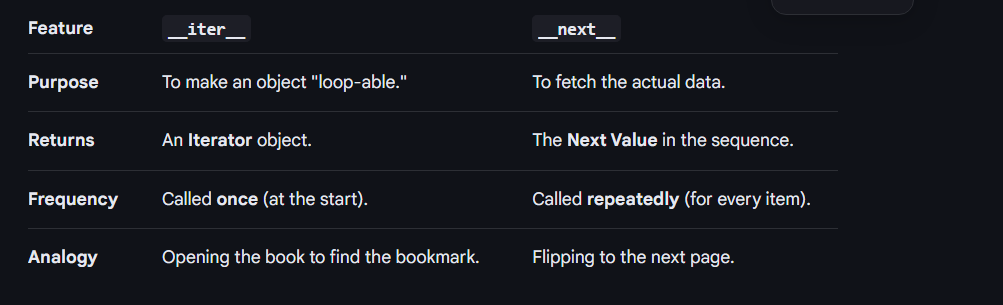

Why does this matter for Generators?
When you write a Generator Function (with yield), Python automatically builds both of these methods for you behind the scenes.
The Generator Object is smart: it has __iter__ (so it works in loops) and it has __next__ (so it knows how to run your code until the next yield).
Does it make sense why you need both? One to "start" the process and one to "step" through it?

range() in Python 3 is not a generator. While it behaves similarly to a generator by producing numbers on demand (lazy evaluation), it is technically a built-in immutable sequence type. 
Here are the key differences:
Type vs. Function: A generator is an iterator created by a function containing yield or a generator expression. range is a class constructor that returns a range object.
Reusable vs. Consumable: Generators are "one-use" iterators; once they are exhausted, they cannot be restarted. A range object is a sequence that can be iterated over multiple times without being exhausted.
Containment & Membership: You can check for membership in a range (e.g., 5 in range(10)) in constant time O(1) because it uses math rather than iteration. Generators require O(n) time as they must iterate until the value is found.
Indexing and Slicing: Unlike generators, range objects support indexing (e.g., range(10)[2]), slicing, and the len() function.
Direct Iteration: You cannot call next() directly on a range object. To iterate step-by-step, you must first create an iterator from it using iter(range(...))

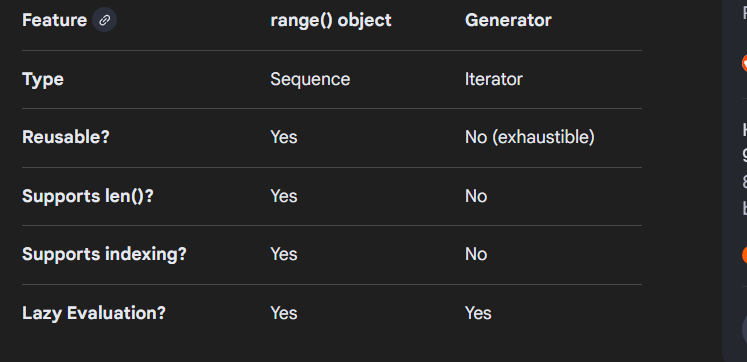

In [5]:
r = range(10)
# next(r)  <-- This will cause a TypeError: 'range' object is not an iterator
print(r)
print(range(2,15))
print(range(5))
# You must get an iterator from it first:
it = iter(r) 
print(next(it)) # Now it works!
print(next(it))


range(0, 10)
range(2, 15)
range(0, 5)
0
1


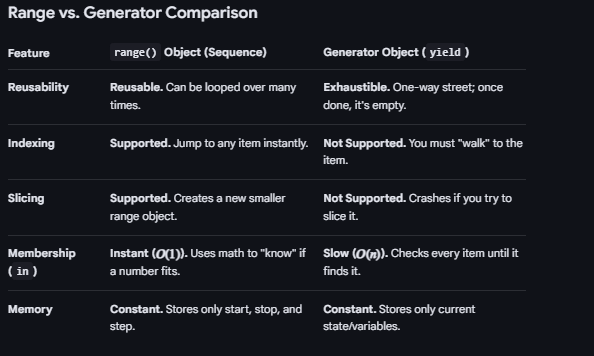

In [6]:
r = range(3)

# 1. Create a "bookmark" for the range
it = iter(r)

print(it) 
# Output: <range_iterator object at 0x...>

# 2. Use the bookmark
print(next(it)) # 0
print(next(it)) # 1


0
1


In [8]:
r = range(5)
gen = (x for x in range(5))

# Range: Loop 1 works, Loop 2 works.
print(list(r), list(r)) # Output: [0, 1, 2] [0, 1, 2]

# Generator: Loop 1 works, Loop 2 is EMPTY.
print(list(gen), list(gen)) # Output: [0, 1, 2] []


[0, 1, 2, 3, 4] [0, 1, 2, 3, 4]
[0, 1, 2, 3, 4] []


In [9]:
r = range(100, 1000)
gen = (x for x in range(100, 1000))

print(r[5])    # Output: 105 (Instant math) O(1) time complexity
# print(gen[5]) # TypeError: 'generator' object is not subscriptable


105


In [10]:
r_slice = range(10)[2:5] #2,3,4 only 5 is not included(important)
print(r_slice) # Output: range(2, 5)
print(list(r_slice))
# gen_slice = gen[2:5] # TypeError: 'generator' object is not subscriptable


range(2, 5)
[2, 3, 4]


In [25]:
r = range(0, 1000000000, 2)
# Range checks if 999 is even and between bounds (Instant)
print(999 in r) # False
print(3444668 in r)
#O(1) time complexity , just maths <>operations hehe
gen = (x for x in range(0, 1000000000, 2))
# Generator has to check 0, 2, 4, 6... until it hits 999 or 1 billion (Slow!)
print(999 in gen) #works but slow O(N)
#omg second "in" in generator was too slow, it actually does not stop at 1000 or so, it completely checks all iuntill its exhausted, as it does not know anything it just keep on generastinbg next numberd and cyhecking 999 , unlike above range where it performs maths directly

False
True
False


How does range calculate step/membership in 



?
It uses a simple Algebraic Formula. When you call 999 in range(0, 1000, 2), Python's internal C-code does these three lightning-fast checks:
Bounds Check: Is 


?
Result: Yes.
Direction Check: Is the step positive or negative? (Ensures 999 is on the "right side" of the start).
Result: Yes.
The "Step" Math (The Magic): Does the difference between the number and the start divide perfectly by the step?
Formula: (number - start) % step == 0
Example: (999 - 0) % 2 is 1.
Result: Since it's not 0, 999 is NOT in the range.
It doesn't matter if the range is 10 or 10 Trillion; the math takes the same amount of time.


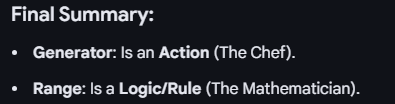

1. The Relationship
__iter__ and __next__ are Methods: These are the "internals" defined inside a class (the engine parts). You usually don't call them directly with the underscores.
iter() and next() are Built-in Functions: These are the "user-facing buttons" (the dashboard).
2. How they connect
When you call the built-in function, it simply goes "under the hood" and calls the corresponding method for you:
Calling iter(my_obj) 
 triggers my_obj.__iter__()
Calling next(my_obj) 
 triggers my_obj.__next__()
3. Why have both?
It's about cleanliness and safety:
Readability: next(g) looks much cleaner in your code than g.__next__().
The "Safety Net": The built-in next() function has extra powers. For example, you can give it a default value: next(g, "End"). If you called the method directly (g.__next__()), you couldn't do that; it would just crash with an error if it was empty.
Consistency: Python uses this "Protocol" everywhere.
len(obj) calls obj.__len__()
print(obj) calls obj.__str__()
Summary for your notes:
Double Underscores (__method__): This is where you define the logic inside the class.
Built-in Functions (func()): This is how you use the logic in your actual program.

Think of it like a specific tool vs. a general category.
1. The Rule: "Every Generator is an Iterator"
A Generator is just a very easy way to write an Iterator. Since a generator has __next__ and __iter__ built-in by Python, it qualifies as an iterator automatically.
2. The Rule: "Every Iterator is an Iterable"
An Iterator must have an __iter__ method (which just returns itself). Because it has that method, it qualifies as an Iterable (something you can put in a for loop).
Why the opposite isn't true (The "Counter-Examples"):
A. An Iterable is NOT always an Iterator
A List is an "Iterable" (you can loop over it), but it is not an "Iterator."
Proof: Try next().
Example:


In [11]:
my_list = [1, 2]
next(my_list) # ERROR! (Lists don't have a bookmark/pointer)


TypeError: 'list' object is not an iterator

A list is the book, but it doesn't have the bookmark until you call iter() on it.



B. An Iterator is NOT always a Generator
You can build a custom Iterator using a class with __next__ and __iter__.
Proof: It works exactly like a generator, but it wasn't made with a function or the yield keyword.
Example:


In [12]:
# This is an Iterator, but NOT a Generator
class MyIter:
    def __init__(self): self.n = 0
    def __next__(self): 
        self.n += 1
        return self.n
    def __iter__(self): return self

it = MyIter()
#it is an iterable and iterater


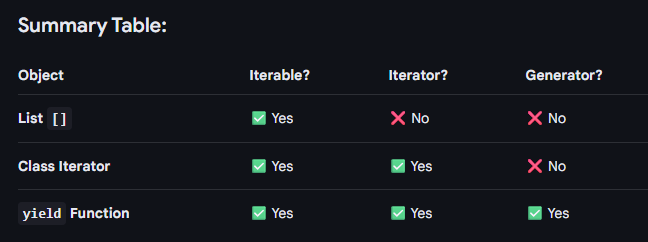

In [13]:
# Generator function for the cube of numbers (power of 3)
def gencubes(n):
    for num in range(n):
        yield num**3

In [15]:
for x in gencubes(7):
    print(x)

0
1
8
27
64
125
216


Great! Now since we have a generator function we don't have to keep track of every single cube we created.

Generators are best for calculating large sets of results (particularly in calculations that involve loops themselves) in cases where we don’t want to allocate the memory for all of the results at the same time. 

Let's create another example generator which calculates [fibonacci](https://en.wikipedia.org/wiki/Fibonacci_number) numbers:

In [16]:
def genfibon(n):
    """
    Generate a fibonnaci sequence up to n
    """
    a = 1
    b = 1
    for _ in range(n):
        yield a
        a,b = b,a+b

In [17]:
for num in genfibon(6):
    print(num)

1
1
2
3
5
8


What if this was a normal function, what would it look like?

In [18]:
def fibon(n):
    a = 1
    b = 1
    output = []
    
    for i in range(n):
        output.append(a)
        a,b = b,a+b
        
    return output

In [19]:
fibon(10)

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55]

Notice that if we call some huge value of n (like 100000) the second function will have to keep track of every single result, when in our case we actually only care about the previous result to generate the next one!

## next() and iter() built-in functions
A key to fully understanding generators is the next() function and the iter() function.

The next() function allows us to access the next element in a sequence. Lets check it out:

In [20]:
def simple_gen():
    for x in range(3):
        yield x

In [21]:
simple_gen()

<generator object simple_gen at 0x000001FEF940E8E0>

In [22]:
# Assign simple_gen 
g = simple_gen()

In [23]:
g() # that makes sense

TypeError: 'generator' object is not callable

In [24]:
print(next(g))

0


In [25]:
print(next(g))

1


In [26]:
print(next(g))

2


In [27]:
print(next(g))

StopIteration: 

After yielding all the values next() caused a StopIteration error. What this error informs us of is that all the values have been yielded. 

You might be wondering that why don’t we get this error while using a for loop? A for loop automatically catches this error and stops calling next(). 

Let's go ahead and check out how to use iter(). You remember that strings are iterables:

In [28]:
tpl = iter((1,2,3))

In [29]:
next(tpl)

1

In [30]:
next(tpl)

2

In [31]:
lst= iter([1,2,3])

In [32]:
next(lst)

1

In [33]:
next(lst)

2

In [34]:
s = 'hello'

#Iterate over string
for let in s:
    print(let)

h
e
l
l
o


But that doesn't mean the string itself is an *iterator*! We can check this with the next() function:

In [35]:
next(s)

TypeError: 'str' object is not an iterator

Interesting, this means that a string object supports iteration, but we can not directly iterate over it as we could with a generator function. The iter() function allows us to do just that!

In [36]:
s_iter = iter(s)

In [37]:
next(s_iter)

'h'

In [38]:
next(s_iter)

'e'

Great! Now you know how to convert objects that are iterable into iterators themselves!

The main takeaway from this lecture is that using the yield keyword at a function will cause the function to become a generator. This change can save you a lot of memory for large use cases. For more information on generators check out:

[Stack Overflow Answer](http://stackoverflow.com/questions/1756096/understanding-generators-in-python)

[Another StackOverflow Answer](http://stackoverflow.com/questions/231767/what-does-the-yield-keyword-do-in-python)